# Modeling — Predicting Electric Vehicle Purchases

Continues from [EDA.ipynb](EDA.ipynb). Metric: **ROC AUC** on `Will_Buy_EV`. AUC only scores the
*ranking* of the predicted probabilities, so calibration, thresholds and class weights don't change it.

## From EDA to modeling decisions

| EDA finding | Decision in this notebook |
|---|---|
| 668,665 train / 286,571 test rows, no missing values | No imputation. |
| Imbalanced target: 17.5% `Yes` | Stratified folds. No resampling or class weights — AUC ignores calibration. |
| `Subsidy_Available = No` → 0.6% buy rate vs 27% with a subsidy | Looks like a gate. §4 tests one model per subsidy segment; §5 measures how much interactions matter at all. |
| `Environmental_Concern_Level` is the strongest signal (corr 0.46): the buy rate climbs from 0.6% to 52% over its 5 levels | Not a straight line in the level → one-hot it for the linear model. |
| `Range_Anxiety_Level`: Low 19% / Medium 4% / High ≈ 0% | One-hot for the linear model; trees split on it natively. |
| `Annual_Income_USD` is the second numeric signal (corr 0.23) | Splines for the linear model, and the focus of feature engineering in §6. |
| Histogram spikes at the minimum: income = 30,000 (9% of rows), commute = 5 km (22%) | The generator clips values → §6 tests explicit floor flags. |
| Age, gender, car type, cars owned and charging stations barely move the buy rate | Kept; the models decide. |
| Train/test feature means agree within 0.3% | §2 confirms with adversarial validation. |

Two things the EDA did not cover:
- **Duplicates.** The EDA's `train.duplicated()` included the unique `id` column, so it could never
  find a duplicate. §1 re-checks on the features only.
- **Synthetic origin.** The competition data was generated from the 10,000-row
  [EV Adoption Behavior and Range Anxiety](https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety)
  survey. Generated data can carry artifacts of the generator — for example in how often exact values
  repeat — and those are worth testing directly (§6).

## Plan

0. Setup
1. Load data
2. Adversarial validation
3. Cross-validation framework
4. Linear baselines — plain vs EDA-informed logistic regression
5. Gradient boosting baselines — LightGBM / XGBoost / CatBoost, and how much interactions matter
6. Feature engineering — ideas from the EDA and from the synthetic origin, each tested on the same folds
7. Hyperparameter tuning — Optuna for all three boosters
8. Final models
9. Ensemble
10. Interpretation — SHAP
11. Diagnostics — ROC, calibration, AUC by segment
12. Submission
13. Summary

**Runtime:** roughly an hour on an 8-core laptop (estimate). Sections 1–6 take about 15 minutes; tuning
(§7) and the final models (§8) take most of the rest. Re-runs can skip tuning with `RUN_TUNING = False`.

The notes after each section quote numbers from development runs on the same folds and seed; a full run
reproduces them up to small differences.

## 0. Setup

In [1]:
import inspect
import json
import re
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")  # set before importing optuna, which triggers tqdm's IProgress warning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit, logit

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    SplineTransformer,
    StandardScaler,
    TargetEncoder,
)

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

NOTEBOOK_START = time.time()
SEED = 42
N_SPLITS = 5
TARGET = "Will_Buy_EV"
DATA_DIR = Path("playground-series-s6e9")
# Optional original survey (§1, §6):
#   kaggle datasets download -d itzzomkar/ev-adoption-behavior-and-range-anxiety -p original-data --unzip
ORIGINAL_PATH = Path("original-data/EV_Adoption_and_Range_Anxiety_Dataset.csv")
ARTIFACTS = Path("artifacts")
(ARTIFACTS / "preds").mkdir(parents=True, exist_ok=True)

# Tuning (§7) is the slowest section. Trials are stored in artifacts/optuna.db, so a stopped or
# repeated run resumes instead of starting over. RUN_TUNING = False reuses artifacts/best_params.json.
RUN_TUNING = True
N_TRIALS = {"lightgbm": 30, "xgboost": 20, "catboost": 10}

# §8 fits every final booster once per seed on each fold and averages the fits: a cheap ensemble that
# steadies the predictions. Each extra seed is another full training run, e.g. [42, 7, 2026] is 3x slower.
FINAL_SEEDS = [SEED]

# Chart colors in a fixed order (colorblind-checked); single-series charts use the first.
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
rng = np.random.default_rng(SEED)

print("lightgbm", lgb.__version__, "| xgboost", xgb.__version__, "| optuna", optuna.__version__)

lightgbm 4.6.0 | xgboost 3.1.3 | optuna 4.8.0


## 1. Load data

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

NUMERIC_COLS = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
]
CATEGORICAL_COLS = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level",
]
FEATURES = NUMERIC_COLS + CATEGORICAL_COLS

y = (train[TARGET] == "Yes").astype(int).values

print("train:", train.shape, " test:", test.shape)
print(f"positive rate: {y.mean():.5f}")
print("duplicate feature rows in train   :", train.duplicated(FEATURES).sum())
print("test rows identical to a train row:", len(test[FEATURES].merge(train[FEATURES], how="inner")))

train: (668665, 15)  test: (286571, 14)
positive rate: 0.17465
duplicate feature rows in train   : 0


test rows identical to a train row: 0


### The original survey

Optional: if the CSV is missing, the one experiment that uses it (§6) is skipped.

In [3]:
def buy_rate(df, col):
    return df.groupby(col)[TARGET].apply(lambda s: (s == "Yes").mean())


if ORIGINAL_PATH.exists():
    original = pd.read_csv(ORIGINAL_PATH)
    y_original = (original[TARGET] == "Yes").astype(int).values
    print("original:", original.shape, f"| positive rate {y_original.mean():.4f}")
    print("missing values:", original[FEATURES].isnull().sum().loc[lambda s: s > 0].to_dict())

    rate_table = pd.concat(
        {
            col: pd.DataFrame(
                {"competition train": buy_rate(train, col), "original survey": buy_rate(original, col)}
            )
            for col in ["Subsidy_Available", "Range_Anxiety_Level", "Environmental_Concern_Level"]
        }
    )
    display(rate_table.round(4))
else:
    original = None
    print(f"{ORIGINAL_PATH} not found — the original-survey experiment in §6 is skipped.")

original: (10000, 15) | positive rate 0.1750
missing values: {'Annual_Income_USD': 178, 'Daily_Commute_km': 181, 'Environmental_Concern_Level': 184}


competition train  original survey
Subsidy_Available           No                 0.0058           0.0253
                            Yes                0.2747           0.2745
Range_Anxiety_Level         High               0.0014           0.0060
                            Low                0.1890           0.1987
                            Medium             0.0417           0.0643
Environmental_Concern_Level 1.0                0.0057           0.0214
                            2.0                0.0214           0.0493
                            3.0                0.1109           0.1445
                            4.0                0.2488           0.2529
                            5.0                0.5183           0.4140

**Notes (development run).** The survey has the same overall buy rate (17.5%) but noticeably *weaker*
relationships than the synthetic data: without a subsidy 2.5% of survey respondents buy vs 0.6% in the
competition data, and at environmental-concern level 5 it is 41% vs 52%. The survey also has ~180 missing
values in each of income, commute and concern level; the competition data has none. So the survey comes
from a visibly different distribution — §6 checks whether its rows help anyway.

## 2. Adversarial validation

The EDA compared train and test feature *means*. A stronger check: train a classifier to tell train
rows from test rows. An AUC near 0.5 means it can't, so the test set comes from the same distribution
and cross-validation scores should carry over to the leaderboard.

In [4]:
adv_X = pd.concat([train[FEATURES], test[FEATURES]], ignore_index=True)
for col in CATEGORICAL_COLS:
    adv_X[col] = adv_X[col].astype("category")
adv_y = np.r_[np.zeros(len(train)), np.ones(len(test))]

adv_oof = np.zeros(len(adv_X))
for trn_idx, val_idx in StratifiedKFold(3, shuffle=True, random_state=SEED).split(adv_X, adv_y):
    adv_model = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.1, num_leaves=63, random_state=SEED, n_jobs=-1, verbose=-1
    )
    adv_model.fit(adv_X.iloc[trn_idx], adv_y[trn_idx])
    adv_oof[val_idx] = adv_model.predict_proba(adv_X.iloc[val_idx])[:, 1]

print(f"adversarial AUC (train vs test): {roc_auc_score(adv_y, adv_oof):.4f}")

adversarial AUC (train vs test): 0.4998


**How to read it.** An AUC close to 0.5 means the classifier can't tell train rows from test rows, so the
CV scores below are fair estimates of leaderboard performance. If it were clearly higher (say above 0.55),
the adversarial model's feature importances would point at the shifted feature — investigate that before
trusting CV.

## 3. Cross-validation framework

`StratifiedKFold(5, shuffle=True)`, with the same folds for every model so all comparisons are
apples-to-apples. `cross_validate_model` collects out-of-fold (OOF) predictions for the AUC estimate and
averages the fold models' test predictions into a submission candidate. The final models' predictions
are also saved to `artifacts/preds/`, so they can be blended later without retraining.

**Comparing two models.** Fold AUCs vary by roughly ±0.0008, but most of that is how hard each fold
happens to be, and every model scored on that fold shares it. The per-fold *difference* between two
models is a much sharper yardstick, so `compare()` reports its mean ± std across the 5 folds. A change is
worth keeping when the mean clearly exceeds the std and the sign agrees across folds.

In [5]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(skf.split(train, y))

results = {}

# LightGBM 4.7 renamed the validation arguments of `fit()` from `eval_set` to
# `eval_X`/`eval_y`; 4.6 and earlier only accept `eval_set`. Detect which one this
# install expects so the notebook runs on either version.
_LGB_USES_EVAL_XY = "eval_X" in inspect.signature(lgb.LGBMClassifier.fit).parameters


def lgb_fit(model, X_trn, y_trn, X_val, y_val, stopping_rounds=150):
    """Fit a LGBMClassifier with early stopping, across LightGBM versions."""
    eval_kwargs = (
        {"eval_X": X_val, "eval_y": y_val}
        if _LGB_USES_EVAL_XY
        else {"eval_set": [(X_val, y_val)]}
    )
    model.fit(
        X_trn,
        y_trn,
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds, verbose=False)],
        **eval_kwargs,
    )
    return model


def store_result(name, oof, test_pred, best_iters=None, seconds=0.0, save=False):
    fold_aucs = [roc_auc_score(y[v], oof[v]) for _, v in folds]
    results[name] = {
        "oof": oof,
        "test_pred": test_pred,
        "auc": roc_auc_score(y, oof),
        "fold_aucs": fold_aucs,
        "best_iters": best_iters or [None] * len(folds),
        "seconds": seconds,
    }
    if save:
        slug = re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")
        np.savez_compressed(
            ARTIFACTS / "preds" / f"{slug}.npz", oof=oof.astype(np.float32), test_pred=test_pred.astype(np.float32)
        )
    return results[name]


def cross_validate_model(name, fit_fold, X_tr, X_te, save=False):
    """Run K-fold CV. `fit_fold(X_trn, y_trn, X_val, y_val)` returns (predict_fn, best_iter)."""
    start = time.time()
    oof = np.zeros(len(X_tr))
    test_pred = np.zeros(len(X_te))
    best_iters = []

    for trn_idx, val_idx in folds:
        predict, best_iter = fit_fold(
            X_tr.iloc[trn_idx], y[trn_idx], X_tr.iloc[val_idx], y[val_idx]
        )
        oof[val_idx] = predict(X_tr.iloc[val_idx])
        test_pred += predict(X_te) / len(folds)
        best_iters.append(best_iter)

    r = store_result(name, oof, test_pred, best_iters, time.time() - start, save)
    print(f"{name:38s} OOF AUC = {r['auc']:.5f}  (fold std {np.std(r['fold_aucs']):.5f})  {r['seconds']:.1f}s")
    if any(b is not None for b in best_iters):
        print(f"{'':38s} best iterations: {best_iters}")
    return r["auc"]


def compare(base, new):
    """Paired comparison of two stored CV runs on the same folds."""
    delta = np.array(results[new]["fold_aucs"]) - np.array(results[base]["fold_aucs"])
    print(f"{new}  vs  {base}: {delta.mean():+.5f} ± {delta.std(ddof=1):.5f}   per fold {np.round(delta, 5)}")
    return delta


def plot_auc(names, title):
    """Dot plot of OOF AUC. The differences live in the 4th decimal, so bars from zero would hide them."""
    table = pd.Series({n: results[n]["auc"] for n in names}).sort_values()
    lo = table.min() - 0.001
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(table) + 1.4))
    ax.hlines(range(len(table)), lo, table.values, color="0.85", lw=1)
    ax.plot(table.values, range(len(table)), "o", color=COLORS[0], markersize=8)
    for i, v in enumerate(table.values):
        ax.annotate(f"{v:.5f}", (v, i), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9)
    ax.set_yticks(range(len(table)), table.index)
    ax.set_xlim(lo, table.max() + 0.0012)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("OOF ROC AUC")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def to_logit(p):
    return logit(np.clip(p, 1e-7, 1 - 1e-7))

In [6]:
CATEGORY_LEVELS = {col: sorted(set(train[col]) | set(test[col])) for col in CATEGORICAL_COLS}


def tree_frame(df):
    """Features with categoricals as pandas `category`, levels shared by train and test (LightGBM / XGBoost)."""
    out = df[FEATURES].copy()
    for col in CATEGORICAL_COLS:
        out[col] = pd.Categorical(out[col], categories=CATEGORY_LEVELS[col])
    return out


def catboost_frame(df):
    """CatBoost takes its categorical features as plain strings."""
    return df.astype({col: str for col in CATEGORICAL_COLS})


X, X_test = tree_frame(train), tree_frame(test)
X.dtypes

Age                               int64
Annual_Income_USD               float64
Daily_Commute_km                float64
Number_of_Cars_Owned              int64
Charging_Stations_Near_Home       int64
Charging_Stations_Near_Work       int64
Environmental_Concern_Level     float64
Gender                         category
City_Type                      category
Current_Car_Type               category
Home_Charging_Possible         category
Subsidy_Available              category
Range_Anxiety_Level            category
dtype: object

## 4. Linear baselines

- **Plain:** scaled numerics + one-hot categoricals — the baseline from the first version of this notebook.
- **EDA splines:** the EDA showed effects a straight line can't follow — the buy rate jumps between
  environmental-concern levels, income and commute have clipped floors, and station/car counts are small
  discrete sets. So: cubic splines for income, commute and age; one-hot for every discrete column; and
  explicit floor flags.
- **Per subsidy segment:** without a subsidy almost nobody buys. If subsidy *gates* the other effects,
  a separate model per segment should beat one shared model.

In [7]:
DISCRETE_NUMERIC_COLS = [
    "Environmental_Concern_Level",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
]
INCOME_FLOOR = train["Annual_Income_USD"].min()
COMMUTE_FLOOR = train["Daily_Commute_km"].min()


def add_floor_flags(df):
    """The EDA histograms spike at the minimum income and commute: values clipped by the generator."""
    return df.assign(
        Income_at_floor=(df["Annual_Income_USD"] <= INCOME_FLOOR).astype(int),
        Commute_at_floor=(df["Daily_Commute_km"] <= COMMUTE_FLOOR).astype(int),
    )


def lr_plain():
    pre = ColumnTransformer(
        [
            ("num", StandardScaler(), NUMERIC_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
        ]
    )
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, random_state=SEED))])


def lr_eda(income_features=False):
    """Splines + one-hot + floor flags; optionally splines on the §6 income features too."""
    def spline():
        return SplineTransformer(n_knots=12, degree=3, extrapolation="constant")

    blocks = [
        ("spline", spline(), ["Annual_Income_USD", "Daily_Commute_km", "Age"]),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLS + DISCRETE_NUMERIC_COLS),
        ("flags", "passthrough", ["Income_at_floor", "Commute_at_floor"]),
    ]
    if income_features:
        blocks += [
            ("income_count", make_pipeline(FunctionTransformer(np.log1p), spline()), ["Income_count"]),
            ("income_te", make_pipeline(FunctionTransformer(to_logit), spline()), ["Annual_Income_USD_te"]),
        ]
    pre = ColumnTransformer(blocks, sparse_threshold=0)
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=3000, random_state=SEED))])


class PerSegmentModel:
    """One model per level of `segment_col`, each fit only on that segment's rows."""

    def __init__(self, make_model, segment_col):
        self.make_model = make_model
        self.segment_col = segment_col

    def fit(self, X, y):
        self.models_ = {}
        for level in X[self.segment_col].unique():
            mask = (X[self.segment_col] == level).values
            self.models_[level] = self.make_model().fit(X[mask], y[mask])
        return self

    def predict_proba(self, X):
        proba = np.zeros((len(X), 2))
        for level, model in self.models_.items():
            mask = (X[self.segment_col] == level).values
            if mask.any():
                proba[mask] = model.predict_proba(X[mask])
        return proba


def sklearn_fold_factory(make_model):
    def fit_fold(X_trn, y_trn, X_val, y_val):
        model = make_model().fit(X_trn, y_trn)
        return (lambda d: model.predict_proba(d)[:, 1]), None

    return fit_fold


X_lr, X_test_lr = add_floor_flags(train[FEATURES]), add_floor_flags(test[FEATURES])

cross_validate_model("LogReg (plain)", sklearn_fold_factory(lr_plain), X_lr, X_test_lr)
cross_validate_model("LogReg (EDA splines)", sklearn_fold_factory(lr_eda), X_lr, X_test_lr)
cross_validate_model(
    "LogReg (EDA splines, per subsidy)",
    sklearn_fold_factory(lambda: PerSegmentModel(lr_eda, "Subsidy_Available")),
    X_lr,
    X_test_lr,
)
print()
compare("LogReg (plain)", "LogReg (EDA splines)")
compare("LogReg (EDA splines)", "LogReg (EDA splines, per subsidy)");

LogReg (plain)                         OOF AUC = 0.93809  (fold std 0.00081)  7.7s


LogReg (EDA splines)                   OOF AUC = 0.93929  (fold std 0.00079)  20.5s


LogReg (EDA splines, per subsidy)      OOF AUC = 0.93927  (fold std 0.00078)  20.3s

LogReg (EDA splines)  vs  LogReg (plain): +0.00120 ± 0.00012   per fold [0.00132 0.00105 0.00132 0.00111 0.0012 ]
LogReg (EDA splines, per subsidy)  vs  LogReg (EDA splines): -0.00002 ± 0.00006   per fold [-1.0e-05 -3.0e-05 -2.0e-05 -1.1e-04  6.0e-05]


**Notes (development runs).** Plain 0.93809 → EDA splines 0.93929: **+0.0012 ± 0.0001**, better on every
fold, so the non-linear shapes the EDA showed are real. The per-subsidy variant scores 0.93927
(−0.00002 ± 0.00006): the gate-like subsidy pattern does *not* need separate models. That points to an
additive effect — no subsidy lowers everyone's log-odds by a similar amount instead of switching the other
features off — so splitting the data only leaves each model fewer rows to learn from. §5 tests the
additivity directly.

## 5. Gradient boosting baselines

Same folds, early stopping on the validation fold (`n_estimators` is only an upper bound).

- **LightGBM** uses the tree shape Optuna found in the first version of this notebook (16 leaves, strong
  regularization) at a fast learning rate of 0.08. It is the reference model for every experiment in §6.
- **XGBoost** and **CatBoost** use the first version's settings. Every categorical has at most 4 levels, so
  CatBoost's `one_hot_max_size=10` one-hot encodes them all and skips its target statistics; with
  `boosting_type="Plain"` that is much faster at the same AUC.

In [8]:
LGB_BASE_PARAMS = dict(
    n_estimators=4000,
    learning_rate=0.08,
    num_leaves=16,
    min_child_samples=178,
    feature_fraction=0.63,
    bagging_fraction=0.65,
    bagging_freq=1,
    lambda_l1=2.2,
    lambda_l2=5.1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)


def lgbm_fold_factory(params=None, stopping_rounds=150):
    config = {**LGB_BASE_PARAMS, **(params or {})}

    def fit_fold(X_trn, y_trn, X_val, y_val):
        model = lgb_fit(lgb.LGBMClassifier(**config), X_trn, y_trn, X_val, y_val, stopping_rounds)
        return (lambda d: model.predict_proba(d)[:, 1]), model.best_iteration_

    return fit_fold


cross_validate_model("LightGBM", lgbm_fold_factory(), X, X_test);

LightGBM                               OOF AUC = 0.94200  (fold std 0.00079)  54.3s
                                       best iterations: [575, 693, 601, 644, 747]


In [9]:
XGB_BASE_PARAMS = dict(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=7,
    tree_method="hist",
    enable_categorical=True,
    eval_metric="auc",
    random_state=SEED,
    n_jobs=-1,
)


def xgb_fold_factory(params=None, stopping_rounds=100):
    config = {**XGB_BASE_PARAMS, **(params or {})}

    def fit_fold(X_trn, y_trn, X_val, y_val):
        model = xgb.XGBClassifier(early_stopping_rounds=stopping_rounds, **config)
        model.fit(X_trn, y_trn, eval_set=[(X_val, y_val)], verbose=False)
        return (lambda d: model.predict_proba(d)[:, 1]), model.best_iteration

    return fit_fold


cross_validate_model("XGBoost", xgb_fold_factory(), X, X_test);

XGBoost                                OOF AUC = 0.94154  (fold std 0.00074)  47.7s
                                       best iterations: [407, 354, 357, 357, 346]


In [10]:
CATBOOST_BASE_PARAMS = dict(
    iterations=1500,
    learning_rate=0.1,
    depth=6,
    eval_metric="AUC",
    cat_features=CATEGORICAL_COLS,
    one_hot_max_size=10,
    boosting_type="Plain",
    random_seed=SEED,
    thread_count=-1,
    verbose=0,
    allow_writing_files=False,  # no catboost_info/ folder
)


def catboost_fold_factory(params=None, stopping_rounds=100):
    config = {**CATBOOST_BASE_PARAMS, **(params or {})}

    def fit_fold(X_trn, y_trn, X_val, y_val):
        model = CatBoostClassifier(early_stopping_rounds=stopping_rounds, **config)
        model.fit(catboost_frame(X_trn), y_trn, eval_set=(catboost_frame(X_val), y_val))
        return (lambda d: model.predict_proba(catboost_frame(d))[:, 1]), model.get_best_iteration()

    return fit_fold


cross_validate_model("CatBoost", catboost_fold_factory(), X, X_test);

CatBoost                               OOF AUC = 0.94174  (fold std 0.00076)  139.5s
                                       best iterations: [630, 611, 817, 661, 500]


### How much do interactions matter?

Depth-1 trees (stumps) each look at a single feature, so a boosted model built from them is *additive*:
it can learn any shape per feature but no interaction between features. If that loses little AUC, the
signal is essentially a sum of per-feature effects — and effort should go into representing individual
features better rather than crossing them.

LightGBM depth-1 (additive)            OOF AUC = 0.94183  (fold std 0.00078)  234.6s
                                       best iterations: [4605, 5590, 5291, 4380, 5045]
LightGBM  vs  LightGBM depth-1 (additive): +0.00017 ± 0.00005   per fold [0.00015 0.00015 0.00014 0.00026 0.00014]


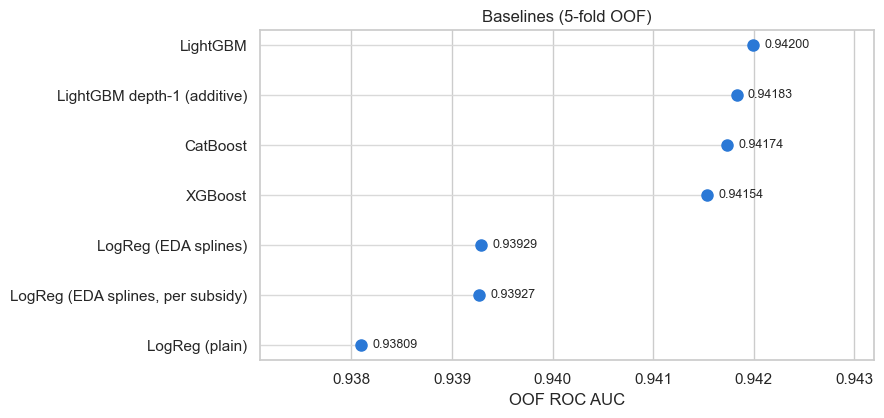

In [11]:
cross_validate_model(
    "LightGBM depth-1 (additive)",
    lgbm_fold_factory(dict(max_depth=1, num_leaves=2, min_child_samples=20, learning_rate=0.3, n_estimators=8000)),
    X,
    X_test,
)
compare("LightGBM depth-1 (additive)", "LightGBM")

plot_auc(list(results), "Baselines (5-fold OOF)")

**Notes (development runs).** On the raw features the three boosters land within 0.0005 of each other —
LightGBM 0.94200, CatBoost 0.94174, XGBoost 0.94154 — about +0.0027 over the EDA-spline logistic
regression. The depth-1 LightGBM scores 0.94183, only **0.00017 ± 0.00005** below the full LightGBM.
Almost all of the signal is additive, a sum of per-feature effects, which is also why the per-subsidy
models in §4 didn't help. The headroom is in how individual features are represented rather than in
crossing them, and that is where §6 looks.

## 6. Feature engineering

Each experiment adds one idea to the §5 LightGBM — same parameters, same folds — and is judged by its
paired gain.

**Ideas from the EDA**
- *Floor flags:* the clipped income/commute spikes as explicit indicators.
- *Discrete numerics as categories:* age, environmental concern, cars owned and station counts take only
  4–45 values; as categories LightGBM can group non-adjacent values in one split.
- *Magic threshold flags:* the millionaire cliff (income ≥ 170,537, 100% buy rate), the income dead
  zone (38k–42k, ~0% buy rate) and the most environment-hostile respondents — sharper, verified versions
  of the floor-flag idea.

**Ideas from the synthetic origin**
- *Original survey rows:* append the 10,000 real rows to every training fold (never to the validation fold).
- *Original survey means:* per-level buy rate from the same survey, as a feature instead of extra rows.
- *Income value frequency* and *income target encoding* — motivated by a closer look at income below.
- *Target encoding the categorical columns too*, not just income.
- *Multi-scale income/commute bins*, target-encoded at two extra smoothing levels (10, 100) — a coarser,
  more heavily regularized view of the same exact-value signal.

In [12]:
X_flags, X_test_flags = add_floor_flags(X), add_floor_flags(X_test)
cross_validate_model("LightGBM + floor flags", lgbm_fold_factory(), X_flags, X_test_flags)


def add_discrete_as_category(df):
    out = df.copy()
    for col in ["Age"] + DISCRETE_NUMERIC_COLS:
        out[f"{col}_cat"] = pd.Categorical(df[col], categories=sorted(set(train[col]) | set(test[col])))
    return out


X_dcat, X_test_dcat = add_discrete_as_category(X), add_discrete_as_category(X_test)
cross_validate_model("LightGBM + discrete as category", lgbm_fold_factory(), X_dcat, X_test_dcat)

if original is not None:
    X_original = tree_frame(original)

    def lgbm_with_original_rows(X_trn, y_trn, X_val, y_val):
        X_aug = pd.concat([X_trn, X_original], ignore_index=True)
        return lgbm_fold_factory()(X_aug, np.r_[y_trn, y_original], X_val, y_val)

    cross_validate_model("LightGBM + original rows", lgbm_with_original_rows, X, X_test)

print()
for name in ["LightGBM + floor flags", "LightGBM + discrete as category", "LightGBM + original rows"]:
    if name in results:
        compare("LightGBM", name)

LightGBM + floor flags                 OOF AUC = 0.94196  (fold std 0.00079)  68.3s
                                       best iterations: [632, 570, 577, 535, 557]


LightGBM + discrete as category        OOF AUC = 0.94135  (fold std 0.00082)  50.1s
                                       best iterations: [548, 391, 413, 386, 294]


LightGBM + original rows               OOF AUC = 0.94198  (fold std 0.00069)  62.2s
                                       best iterations: [694, 661, 523, 495, 604]

LightGBM + floor flags  vs  LightGBM: -0.00003 ± 0.00002   per fold [-3.e-05 -1.e-05 -3.e-05 -5.e-05 -4.e-05]
LightGBM + discrete as category  vs  LightGBM: -0.00064 ± 0.00009   per fold [-0.00061 -0.00078 -0.00053 -0.00065 -0.00063]
LightGBM + original rows  vs  LightGBM: -0.00001 ± 0.00014   per fold [ 2.3e-04 -2.0e-05 -6.0e-05 -1.1e-04 -8.0e-05]


In [13]:
def add_magic_flags(df):
    """Point anomalies verified on this exact income/concern scale: a 100% buy-rate cliff above
    170,537, a near-zero dead zone at 38k-42k, and near-zero buyers among the most
    environment-hostile respondents."""
    return df.assign(
        Income_millionaire_cliff=(df["Annual_Income_USD"] >= 170537).astype(int),
        Income_dead_zone=df["Annual_Income_USD"].between(38000, 42000).astype(int),
        Env_hater=(df["Environmental_Concern_Level"] == 1).astype(int),
    )


X_magic, X_test_magic = add_magic_flags(X), add_magic_flags(X_test)
cross_validate_model("LightGBM + magic flags", lgbm_fold_factory(), X_magic, X_test_magic)
compare("LightGBM", "LightGBM + magic flags")

LightGBM + magic flags                 OOF AUC = 0.94207  (fold std 0.00079)  66.4s
                                       best iterations: [714, 718, 595, 534, 535]
LightGBM + magic flags  vs  LightGBM: +0.00008 ± 0.00001   per fold [9.e-05 6.e-05 8.e-05 7.e-05 8.e-05]


array([9.16936265e-05, 5.85492773e-05, 8.49984317e-05, 6.57743554e-05,
       7.80518678e-05])

In [14]:
ORG_MEAN_COLS = CATEGORICAL_COLS + DISCRETE_NUMERIC_COLS + ["Age"]


def add_original_means(df):
    """Per-level buy rate from the 10,000-row original survey, as a feature. Every level here has
    at least 150 original rows (unlike the continuous income/commute columns), so the means are
    stable enough to trust."""
    out = df.copy()
    for col in ORG_MEAN_COLS:
        level_means = buy_rate(original, col)
        out[f"{col}_org_mean"] = df[col].map(level_means).astype(float).fillna(y_original.mean())
    return out


if original is not None:
    X_orgmean, X_test_orgmean = add_original_means(X), add_original_means(X_test)
    cross_validate_model("LightGBM + original means", lgbm_fold_factory(), X_orgmean, X_test_orgmean)
    compare("LightGBM", "LightGBM + original means")

LightGBM + original means              OOF AUC = 0.94190  (fold std 0.00078)  59.8s
                                       best iterations: [615, 490, 555, 564, 573]
LightGBM + original means  vs  LightGBM: -0.00010 ± 0.00005   per fold [-5.0e-05 -1.6e-04 -1.1e-04 -5.0e-05 -1.1e-04]


### A closer look at income values

The EDA treated income as a smooth distribution with a spike at 30,000. But it has 13,214 distinct
values across 668k rows, and some exact values repeat far more often than a smooth distribution would
produce. If the generator reuses particular values, then *how often* a value repeats, and *which label*
rows with that value tend to have, could carry signal that a smooth income feature can't.

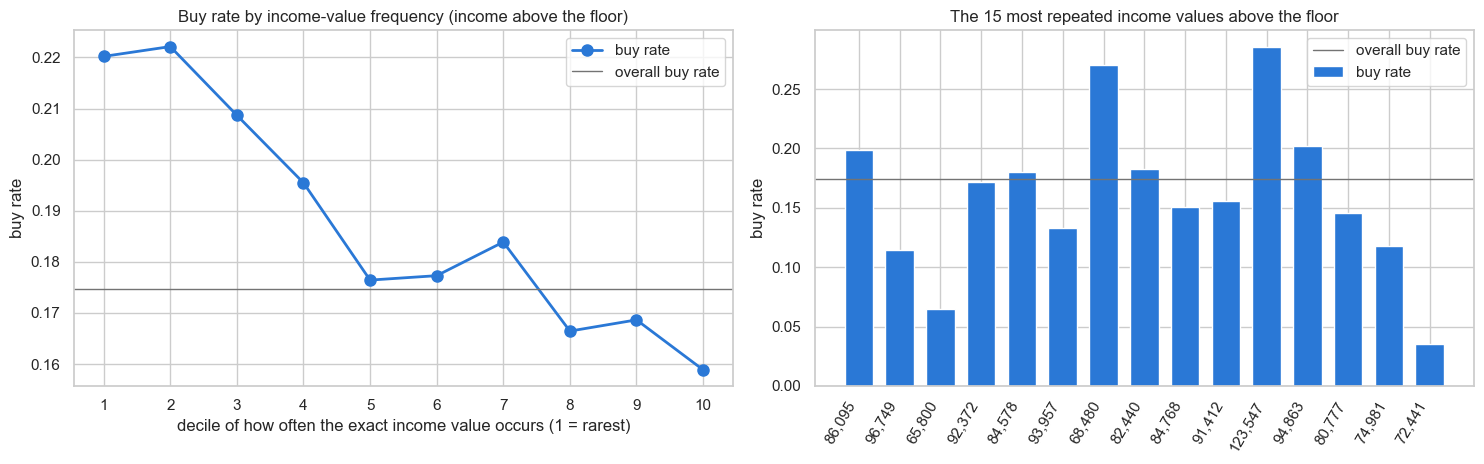

floor value 30,000: 87,881 rows in train + test, buy rate 0.044


,count range,buy rate
1,"(0.999, 56.0]",0.220
2,"(56.0, 91.0]",0.222
3,"(91.0, 124.0]",0.209
4,"(124.0, 155.0]",0.195
5,"(155.0, 185.0]",0.176
6,"(185.0, 216.0]",0.177
7,"(216.0, 254.0]",0.184
8,"(254.0, 317.0]",0.166
9,"(317.0, 523.0]",0.169
10,"(523.0, 1552.0]",0.159


In [15]:
INCOME_COUNTS = pd.concat([train["Annual_Income_USD"], test["Annual_Income_USD"]]).value_counts()

income = pd.DataFrame(
    {"income": train["Annual_Income_USD"], "count": train["Annual_Income_USD"].map(INCOME_COUNTS), "bought": y}
)
above_floor = income[income["income"] > INCOME_FLOOR]
by_count_decile = above_floor.groupby(
    pd.qcut(above_floor["count"], 10, duplicates="drop"), observed=True
)["bought"].mean()
deciles = range(1, len(by_count_decile) + 1)
most_repeated = (
    above_floor.groupby("income")
    .agg(count=("count", "first"), buy_rate=("bought", "mean"))
    .sort_values("count", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(deciles, by_count_decile.values, "o-", color=COLORS[0], lw=2, markersize=8, label="buy rate")
axes[0].axhline(y.mean(), color="0.45", lw=1, label="overall buy rate")
axes[0].set_xticks(deciles)
axes[0].set_xlabel("decile of how often the exact income value occurs (1 = rarest)")
axes[0].set_ylabel("buy rate")
axes[0].set_title("Buy rate by income-value frequency (income above the floor)")
axes[0].legend()

axes[1].bar(range(len(most_repeated)), most_repeated["buy_rate"], color=COLORS[0], width=0.7, label="buy rate")
axes[1].axhline(y.mean(), color="0.45", lw=1, label="overall buy rate")
axes[1].set_xticks(range(len(most_repeated)), [f"{v:,.0f}" for v in most_repeated.index], rotation=60, ha="right")
axes[1].set_ylabel("buy rate")
axes[1].set_title("The 15 most repeated income values above the floor")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"floor value {INCOME_FLOOR:,.0f}: {INCOME_COUNTS[INCOME_FLOOR]:,} rows in train + test, "
      f"buy rate {income.loc[income['income'] == INCOME_FLOOR, 'bought'].mean():.3f}")
pd.DataFrame({"count range": by_count_decile.index.astype(str), "buy rate": by_count_decile.values.round(3)}, index=deciles)

Two features follow from this:

- **`Income_count`** — how often the exact income value occurs in train + test. It uses no labels, so
  computing it on train and test together is safe.
- **`Annual_Income_USD_te`** — target encoding of the exact income value: the smoothed buy rate of
  training rows with that value. It *does* use labels, so it must be fit inside each training fold.
  `FoldTargetEncoder` wraps scikit-learn's `TargetEncoder`, which cross-fits the training rows (a row's
  own label never feeds its own encoding) and encodes validation and test rows from the whole training
  fold. Rare values are shrunk toward the overall rate (`smooth="auto"`).

In [16]:
def add_income_count(df):
    return df.assign(Income_count=df["Annual_Income_USD"].map(INCOME_COUNTS).astype(float))


class FoldTargetEncoder:
    """Target-encode columns with the labels of one training fold only. `smooth` and `suffix` are
    exposed so the same class can produce several encodings of the same columns at once (§6.3)."""

    def __init__(self, cols, smooth="auto", suffix="_te"):
        self.cols = list(cols)
        self.smooth = smooth
        self.suffix = suffix

    def fit(self, X, y):
        self.encoder_ = TargetEncoder(target_type="binary", smooth=self.smooth, cv=5, shuffle=True, random_state=SEED)
        # fit_transform cross-fits: each training row is encoded from the other 4/5 of the fold
        self.train_frame_ = self._attach(X, self.encoder_.fit_transform(X[self.cols], y))
        return self

    def transform(self, X):
        return self._attach(X, self.encoder_.transform(X[self.cols]))

    def _attach(self, X, encoded):
        out = X.copy()
        for i, col in enumerate(self.cols):
            out[f"{col}{self.suffix}"] = encoded[:, i]
        return out


TE_COLS = ["Annual_Income_USD"]


def with_target_encoding(fit_fold_fn, cols=TE_COLS):
    """Wrap a fold-fitting function so the target encoder is fit on the training fold only."""

    def fit_fold(X_trn, y_trn, X_val, y_val):
        encoder = FoldTargetEncoder(cols).fit(X_trn, y_trn)
        predict, best_iter = fit_fold_fn(encoder.train_frame_, y_trn, encoder.transform(X_val), y_val)
        return (lambda d: predict(encoder.transform(d))), best_iter

    return fit_fold


X_fe, X_test_fe = add_income_count(X), add_income_count(X_test)

cross_validate_model("LightGBM + income count", lgbm_fold_factory(), X_fe, X_test_fe)
cross_validate_model("LightGBM + income count + TE", with_target_encoding(lgbm_fold_factory()), X_fe, X_test_fe)
print()
compare("LightGBM", "LightGBM + income count")
compare("LightGBM + income count", "LightGBM + income count + TE");

LightGBM + income count                OOF AUC = 0.94310  (fold std 0.00071)  87.2s
                                       best iterations: [1091, 1037, 970, 633, 1147]


LightGBM + income count + TE           OOF AUC = 0.94555  (fold std 0.00065)  53.0s
                                       best iterations: [601, 430, 559, 434, 451]

LightGBM + income count  vs  LightGBM: +0.00110 ± 0.00015   per fold [0.0013  0.00112 0.00112 0.00088 0.0011 ]
LightGBM + income count + TE  vs  LightGBM + income count: +0.00244 ± 0.00008   per fold [0.00257 0.00238 0.00238 0.00242 0.00247]


In [17]:
CATEGORICAL_TE_COLS = TE_COLS + CATEGORICAL_COLS

cross_validate_model(
    "LightGBM + income count + TE (+ categoricals)",
    with_target_encoding(lgbm_fold_factory(), cols=CATEGORICAL_TE_COLS),
    X_fe,
    X_test_fe,
)
compare("LightGBM + income count + TE", "LightGBM + income count + TE (+ categoricals)")

LightGBM + income count + TE (+ categoricals) OOF AUC = 0.94552  (fold std 0.00064)  58.1s
                                       best iterations: [476, 582, 636, 381, 503]
LightGBM + income count + TE (+ categoricals)  vs  LightGBM + income count + TE: -0.00003 ± 0.00003   per fold [-3.e-05 -1.e-05 -6.e-05  0.e+00 -4.e-05]


array([-3.35776145e-05, -1.03395499e-05, -6.47863669e-05,  1.09970452e-06,
       -3.52060608e-05])

In [18]:
def add_income_commute_bins(df):
    """Coarser multi-resolution keys for the same generator artifact the income target encoding above
    exploits: rounding to the nearest 100 / 1000 groups rare exact values into bins with more rows each."""
    return df.assign(
        Income_bin100=(df["Annual_Income_USD"] // 100).astype(int).astype(str),
        Income_bin1000=(df["Annual_Income_USD"] // 1000).astype(int).astype(str),
        Commute_int=df["Daily_Commute_km"].astype(int).astype(str),
    )


BIN_COLS = ["Income_bin100", "Income_bin1000", "Commute_int"]


def with_multi_smooth_encoding(fit_fold_fn, cols, smooths=(10.0, 100.0)):
    """Chain one fold-safe `FoldTargetEncoder` per smoothing level onto `cols`, then drop the raw string
    keys — LightGBM can't take them as-is since they're plain strings, not `category` dtype, and they
    exist only to be encoded. Heavier smoothing (e.g. 100) shrinks each bin's encoding toward the global
    rate, regularizing the narrower bins instead of discarding them outright."""

    def fit_fold(X_trn, y_trn, X_val, y_val):
        X_trn_enc, X_val_enc = X_trn, X_val
        encoders = []
        for s in smooths:
            enc = FoldTargetEncoder(cols, smooth=s, suffix=f"_te{int(s)}").fit(X_trn_enc, y_trn)
            encoders.append(enc)
            X_trn_enc, X_val_enc = enc.train_frame_, enc.transform(X_val_enc)
        predict, best_iter = fit_fold_fn(X_trn_enc.drop(columns=cols), y_trn, X_val_enc.drop(columns=cols), y_val)

        def predict_chained(d):
            for enc in encoders:
                d = enc.transform(d)
            return predict(d.drop(columns=cols))

        return predict_chained, best_iter

    return fit_fold


def with_target_encoding_and_bins(fit_fold_fn):
    """§6's income TE, chained with the multi-scale bin TE at two extra smoothing levels."""
    return with_target_encoding(with_multi_smooth_encoding(fit_fold_fn, BIN_COLS))


X_bins, X_test_bins = add_income_commute_bins(X_fe), add_income_commute_bins(X_test_fe)

cross_validate_model(
    "LightGBM + income count + TE + multi-scale bins",
    with_target_encoding_and_bins(lgbm_fold_factory()),
    X_bins,
    X_test_bins,
)
compare("LightGBM + income count + TE", "LightGBM + income count + TE + multi-scale bins")

LightGBM + income count + TE + multi-scale bins OOF AUC = 0.94581  (fold std 0.00062)  57.6s
                                       best iterations: [475, 383, 455, 381, 583]
LightGBM + income count + TE + multi-scale bins  vs  LightGBM + income count + TE: +0.00026 ± 0.00005   per fold [0.00027 0.00029 0.00017 0.00029 0.0003 ]


array([0.00027277, 0.00028771, 0.00016549, 0.00028657, 0.00029726])

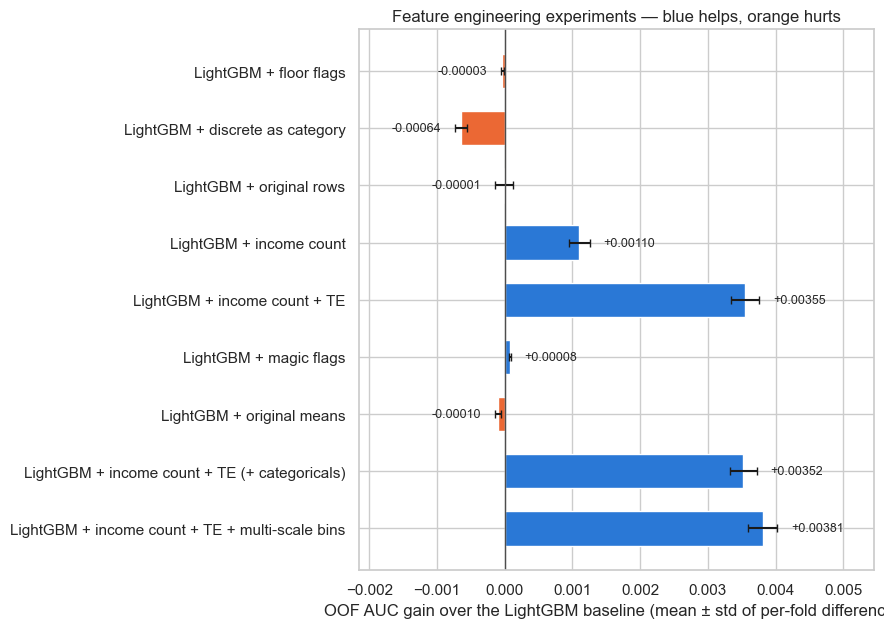

,gain,std
experiment,,
LightGBM + floor flags,-0.00003,0.00002
LightGBM + discrete as category,-0.00064,0.00009
LightGBM + original rows,-0.00001,0.00014
LightGBM + income count,0.00110,0.00015
LightGBM + income count + TE,0.00355,0.00021
LightGBM + magic flags,0.00008,0.00001
LightGBM + original means,-0.00010,0.00005
LightGBM + income count + TE (+ categoricals),0.00352,0.00020
LightGBM + income count + TE + multi-scale bins,0.00381,0.00022


In [19]:
fe_runs = [
    name
    for name in [
        "LightGBM + floor flags",
        "LightGBM + discrete as category",
        "LightGBM + original rows",
        "LightGBM + income count",
        "LightGBM + income count + TE",
        "LightGBM + magic flags",
        "LightGBM + original means",
        "LightGBM + income count + TE (+ categoricals)",
        "LightGBM + income count + TE + multi-scale bins",
    ]
    if name in results
]
fe_deltas = pd.DataFrame(
    [
        {"experiment": name, "gain": d.mean(), "std": d.std(ddof=1)}
        for name in fe_runs
        for d in [np.array(results[name]["fold_aucs"]) - np.array(results["LightGBM"]["fold_aucs"])]
    ]
).set_index("experiment")

fig, ax = plt.subplots(figsize=(9, 0.55 * len(fe_deltas) + 1.5))
bar_colors = [COLORS[0] if g > 0 else COLORS[1] for g in fe_deltas["gain"]]
ax.barh(fe_deltas.index, fe_deltas["gain"], xerr=fe_deltas["std"], color=bar_colors, height=0.6, capsize=3)
ax.axvline(0, color="0.3", lw=1)
lo = min(0.0, (fe_deltas["gain"] - fe_deltas["std"]).min())
hi = max(0.0, (fe_deltas["gain"] + fe_deltas["std"]).max())
width = hi - lo
for i, (g, s) in enumerate(zip(fe_deltas["gain"], fe_deltas["std"])):
    ax.annotate(
        f"{g:+.5f}", (g + np.sign(g) * s, i), xytext=(10 if g >= 0 else -10, 0), textcoords="offset points",
        ha="left" if g >= 0 else "right", va="center", fontsize=9,
    )
ax.set_xlim(lo - (0.3 * width if lo < 0 else 0.05 * width), hi + 0.3 * width)
ax.invert_yaxis()
ax.set_xlabel("OOF AUC gain over the LightGBM baseline (mean ± std of per-fold differences)")
ax.set_title("Feature engineering experiments — blue helps, orange hurts")
plt.tight_layout()
plt.show()

fe_deltas.round(5)

**Notes (development runs)** — paired gains over the LightGBM baseline (0.94200):

| Experiment | Gain | Verdict |
|---|---|---|
| Floor flags | −0.00003 | a split at the minimum already isolates the floor |
| Discrete numerics as categories | ≈ −0.0006 | categorical splits overfit |
| Original survey rows | −0.00001 | different relationships (§1) — no help |
| Income count | **+0.00110 ± 0.00015** | kept |
| Income count + income target encoding | **+0.00355 ± 0.00021** (AUC 0.94555) | kept |
| Magic threshold flags (millionaire cliff, dead zone, env-hater) | **+0.00008 ± 0.00001** | small but positive on every fold — kept |
| Original survey means (per-level buy rate as a feature) | −0.00010 ± 0.00005 | confirms §1: the survey's relationships are too different to transfer — dropped |
| Target encoding the categorical columns too | −0.00003 ± 0.00003 | within noise — LightGBM already splits low-cardinality categoricals natively — dropped |
| + Multi-scale income/commute bins, TE'd at smooth=10 and smooth=100 | **+0.00026 ± 0.00005** (AUC 0.94581, on top of income count + TE) | kept — the single largest gain since the income target encoding itself |

The target encoding adds **+0.0024** on top of the count, higher on every fold. Income *value identity* is
the big win: the generator reuses specific income values, and which label goes with a value carries over
from training rows to validation rows. It's a property of how this synthetic data was made rather than of
real buyers, but it's legitimate here — neither feature sees validation labels.

The multi-scale bins extend the same idea to coarser resolutions (÷100, ÷1000) with heavier smoothing,
picking up rows the exact-value encoding is too sparse to help. §7–8 now tune and fit on
`add_income_commute_bins(add_magic_flags(X_fe))` (`X_final`/`X_test_final`) through
`with_target_encoding_and_bins`, so `STUDY_VERSION` was bumped to `"income_te_bins_v1"` — the old
`best_params.json`/Optuna trials were tuned on a different feature set and don't apply here.

Also tried during development and left out: counts for every numeric column (−0.0002 vs the income count
alone), target-encoding commute as well (+0.00006), the survey's buy rate per income value (+0.00002 once
the target encoding is in), income crossed with subsidy or concern level (−0.00016), and target-encoded
pairs of the original features (−0.0005).

## 7. Hyperparameter tuning — Optuna

Selected features: the 13 raw columns + `Income_count` + the fold-fitted income target encoding.

All three boosters are tuned with Optuna's TPE sampler. To keep a trial cheap:
- it scores a single holdout split — the first CV fold — whose target encoder is fit once, up front;
- it uses a fixed learning rate of 0.1 with early stopping. Tree shape and regularization carry over to a
  lower learning rate, which §8 uses for the final models.

Trials are stored in `artifacts/optuna.db`: re-running this section resumes the studies instead of
repeating them. Change `STUDY_VERSION` after changing the feature set so old trials aren't reused.

In [20]:
STUDY_VERSION = "income_te_bins_v1"  # bumped: §6 found magic flags + multi-scale bins worth keeping
OPTUNA_STORAGE = f"sqlite:///{ARTIFACTS / 'optuna.db'}"
BEST_PARAMS_PATH = ARTIFACTS / "best_params.json"
TUNING_LR = 0.1

X_final = add_income_commute_bins(add_magic_flags(X_fe))
X_test_final = add_income_commute_bins(add_magic_flags(X_test_fe))

hold_trn, hold_val = folds[0]
y_h_trn, y_h_val = y[hold_trn], y[hold_val]

_captured = {}


def _capture_fit_fold(X_trn, y_trn, X_val, y_val):
    """Stand-in for a real fit: just records the encoded frames so tuning reuses the exact same
    encoding chain (income TE + multi-scale bin TE) as the final models, instead of a second copy."""
    _captured["X_trn"], _captured["X_val"] = X_trn, X_val
    return (lambda d: d), None


with_target_encoding_and_bins(_capture_fit_fold)(X_final.iloc[hold_trn], y_h_trn, X_final.iloc[hold_val], y_h_val)
H_trn, H_val = _captured["X_trn"], _captured["X_val"]
H_trn_cb, H_val_cb = catboost_frame(H_trn), catboost_frame(H_val)


def lgbm_objective(trial):
    params = dict(
        num_leaves=trial.suggest_int("num_leaves", 4, 64, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 1000, log=True),
        feature_fraction=trial.suggest_float("feature_fraction", 0.4, 1.0),
        bagging_fraction=trial.suggest_float("bagging_fraction", 0.5, 1.0),
        lambda_l1=trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
        lambda_l2=trial.suggest_float("lambda_l2", 1e-3, 30.0, log=True),
    )
    model = lgb.LGBMClassifier(**{**LGB_BASE_PARAMS, **params, "learning_rate": TUNING_LR})
    lgb_fit(model, H_trn, y_h_trn, H_val, y_h_val, stopping_rounds=100)
    return roc_auc_score(y_h_val, model.predict_proba(H_val)[:, 1])


def xgb_objective(trial):
    params = dict(
        max_depth=trial.suggest_int("max_depth", 2, 8),
        min_child_weight=trial.suggest_float("min_child_weight", 1.0, 200.0, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    )
    model = xgb.XGBClassifier(
        **{**XGB_BASE_PARAMS, **params, "n_estimators": 4000, "learning_rate": TUNING_LR},
        early_stopping_rounds=100,
    )
    model.fit(H_trn, y_h_trn, eval_set=[(H_val, y_h_val)], verbose=False)
    return roc_auc_score(y_h_val, model.predict_proba(H_val)[:, 1])


def catboost_objective(trial):
    params = dict(
        depth=trial.suggest_int("depth", 3, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 50.0, log=True),
        random_strength=trial.suggest_float("random_strength", 0.1, 10.0, log=True),
        # CatBoost's default MVS bootstrap uses `subsample`; `bagging_temperature` would be silently ignored
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
    )
    model = CatBoostClassifier(
        **{**CATBOOST_BASE_PARAMS, **params, "iterations": 4000, "learning_rate": TUNING_LR},
        early_stopping_rounds=100,
    )
    model.fit(H_trn_cb, y_h_trn, eval_set=(H_val_cb, y_h_val))
    return roc_auc_score(y_h_val, model.predict_proba(H_val_cb)[:, 1])


def completed_trials(study):
    # Only COMPLETE trials carry a value; FAIL / RUNNING trials (e.g. from an interrupted run) do not.
    return [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]


def run_study(model_name, objective, n_trials):
    study = optuna.create_study(
        study_name=f"{model_name}_{STUDY_VERSION}",
        storage=OPTUNA_STORAGE,
        load_if_exists=True,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    start = time.time()
    # Catching KeyboardInterrupt keeps the finished trials usable if the cell is stopped early.
    try:
        remaining = n_trials - len(completed_trials(study))
        if remaining > 0:
            study.optimize(objective, n_trials=remaining)
    except KeyboardInterrupt:
        print("interrupted — keeping the trials that finished")
    if not completed_trials(study):
        raise RuntimeError(f"No {model_name} trial finished — re-run this cell, or lower N_TRIALS.")
    print(
        f"{model_name:9s} {len(completed_trials(study))} trials ({time.time() - start:.0f}s this run)"
        f"  best holdout AUC {study.best_value:.5f}"
    )
    return study

In [21]:
if RUN_TUNING:
    studies = {
        "lightgbm": run_study("lightgbm", lgbm_objective, N_TRIALS["lightgbm"]),
        "xgboost": run_study("xgboost", xgb_objective, N_TRIALS["xgboost"]),
        "catboost": run_study("catboost", catboost_objective, N_TRIALS["catboost"]),
    }
    best_params = {name: study.best_params for name, study in studies.items()}
    BEST_PARAMS_PATH.write_text(json.dumps(best_params, indent=2))
else:
    studies = {}
    best_params = json.loads(BEST_PARAMS_PATH.read_text())

print(json.dumps(best_params, indent=2))

lightgbm  30 trials (293s this run)  best holdout AUC 0.94500


xgboost   20 trials (247s this run)  best holdout AUC 0.94493


catboost  10 trials (256s this run)  best holdout AUC 0.94508
{
  "lightgbm": {
    "num_leaves": 19,
    "max_depth": 3,
    "min_child_samples": 138,
    "feature_fraction": 0.5443959971721981,
    "bagging_fraction": 0.8114793999671008,
    "lambda_l1": 0.0010369674490842975,
    "lambda_l2": 28.79299118870215
  },
  "xgboost": {
    "max_depth": 4,
    "min_child_weight": 1.0432136961499219,
    "subsample": 0.9743245943075546,
    "colsample_bytree": 0.6277625460521342,
    "reg_lambda": 1.3824927646516998,
    "reg_alpha": 0.6146439247862415
  },
  "catboost": {
    "depth": 5,
    "l2_leaf_reg": 41.23206532618726,
    "random_strength": 2.9106359131330706,
    "subsample": 0.7993292420985183
  }
}


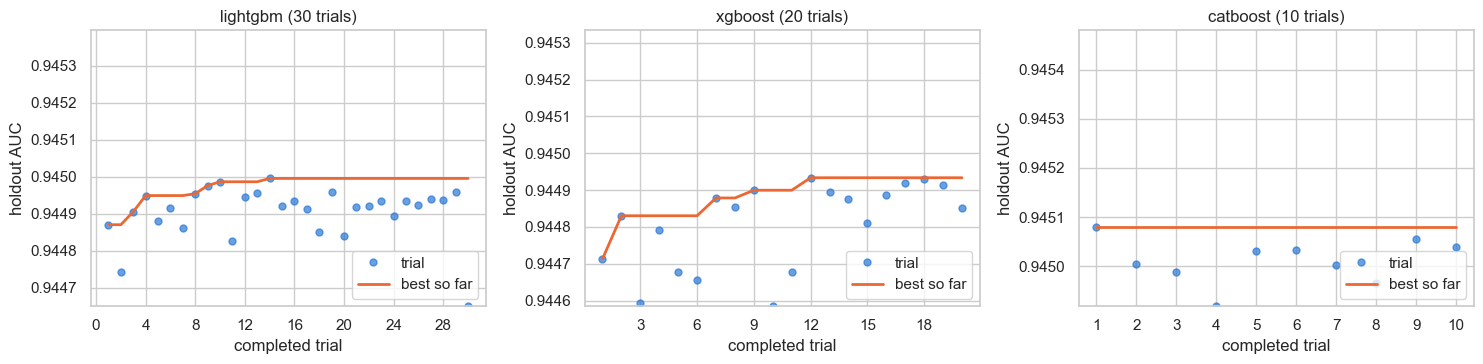

In [22]:
if studies:
    fig, axes = plt.subplots(1, len(studies), figsize=(15, 3.8))
    for ax, (name, study) in zip(axes, studies.items()):
        values = [t.value for t in completed_trials(study)]
        trial_nums = range(1, len(values) + 1)
        ax.plot(trial_nums, values, "o", color=COLORS[0], markersize=5, alpha=0.7, label="trial")
        ax.plot(trial_nums, np.maximum.accumulate(values), color=COLORS[1], lw=2, label="best so far")
        ax.set_ylim(max(min(values), max(values) - 0.003), max(values) + 0.0004)
        ax.set_title(f"{name} ({len(values)} trials)")
        ax.set_xlabel("completed trial")
        ax.set_ylabel("holdout AUC")
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

**What to look for.** §5 found the signal almost additive, so expect the searches to prefer shallow,
strongly regularized trees (small `max_depth` / `num_leaves` / `depth`, large `min_child_samples` /
`min_child_weight`). Holdout AUC at learning rate 0.1 only ranks trials; §8 re-scores the winners with
5-fold CV at a lower rate. If a best-so-far curve is still climbing at its last trial, raise that model's
`N_TRIALS` and re-run — finished trials are reused.

## 8. Final models

The tuned parameters at a lower learning rate (with more patience for early stopping), 5-fold CV on the
selected features. Every fold fits its own income target encoder. Each booster is fit once per seed in
`FINAL_SEEDS` and the fits are averaged. The linear model gets the same two income features, as splines.

In [23]:
FINAL_LR = {"lightgbm": 0.03, "xgboost": 0.03, "catboost": 0.06}


def seed_averaged(make_fit_fold, seeds=FINAL_SEEDS):
    """Fit one model per seed on the same fold and average their predictions.

    `make_fit_fold(seed)` returns a fold-fitting function. With a single seed this is a plain fit.
    """

    def fit_fold(X_trn, y_trn, X_val, y_val):
        fits = [make_fit_fold(seed)(X_trn, y_trn, X_val, y_val) for seed in seeds]
        best_iter = int(np.mean([best for _, best in fits]))
        return (lambda d: np.mean([predict(d) for predict, _ in fits], axis=0)), best_iter

    return fit_fold


cross_validate_model(
    "LightGBM (tuned)",
    with_target_encoding_and_bins(
        seed_averaged(
            lambda seed: lgbm_fold_factory(
                {
                    **best_params["lightgbm"],
                    "learning_rate": FINAL_LR["lightgbm"],
                    "n_estimators": 20000,
                    "random_state": seed,
                },
                stopping_rounds=300,
            )
        )
    ),
    X_final,
    X_test_final,
    save=True,
);

LightGBM (tuned)                       OOF AUC = 0.94595  (fold std 0.00063)  1184.9s
                                       best iterations: [2941, 2440, 3073, 2252, 2987]


In [24]:
cross_validate_model(
    "XGBoost (tuned)",
    with_target_encoding_and_bins(
        seed_averaged(
            lambda seed: xgb_fold_factory(
                {
                    **best_params["xgboost"],
                    "learning_rate": FINAL_LR["xgboost"],
                    "n_estimators": 20000,
                    "random_state": seed,
                },
                stopping_rounds=300,
            )
        )
    ),
    X_final,
    X_test_final,
    save=True,
);

XGBoost (tuned)                        OOF AUC = 0.94596  (fold std 0.00063)  417.9s
                                       best iterations: [1534, 1476, 1776, 1627, 1556]


In [25]:
cross_validate_model(
    "CatBoost (tuned)",
    with_target_encoding_and_bins(
        seed_averaged(
            lambda seed: catboost_fold_factory(
                {
                    **best_params["catboost"],
                    "learning_rate": FINAL_LR["catboost"],
                    "iterations": 20000,
                    "random_seed": seed,
                },
                stopping_rounds=300,
            )
        )
    ),
    X_final,
    X_test_final,
    save=True,
);

CatBoost (tuned)                       OOF AUC = 0.94596  (fold std 0.00057)  205.8s
                                       best iterations: [1192, 926, 1173, 988, 1056]


In [26]:
X_lr_fe, X_test_lr_fe = add_income_count(X_lr), add_income_count(X_test_lr)

cross_validate_model(
    "LogReg (EDA + income)",
    with_target_encoding(sklearn_fold_factory(lambda: lr_eda(income_features=True))),
    X_lr_fe,
    X_test_lr_fe,
    save=True,
)
print()
compare("LogReg (EDA splines)", "LogReg (EDA + income)")
compare("LightGBM + income count + TE + multi-scale bins", "LightGBM (tuned)");

LogReg (EDA + income)                  OOF AUC = 0.94417  (fold std 0.00062)  21.2s

LogReg (EDA + income)  vs  LogReg (EDA splines): +0.00488 ± 0.00020   per fold [0.00522 0.00482 0.00467 0.00482 0.00489]
LightGBM (tuned)  vs  LightGBM + income count + TE + multi-scale bins: +0.00014 ± 0.00002   per fold [0.00012 0.00015 0.00015 0.00011 0.00017]


**What to expect.** In development runs with *untuned* settings on these same features, XGBoost scored
0.94561, CatBoost 0.94549 and the spline logistic regression ≈ 0.944, so the tuned boosters should land
around 0.9456 or a little above. The two `compare` lines show what the income features did for the linear
model, and what tuning plus the lower learning rate added on top of §6's LightGBM.

## 9. Ensemble

The four final models are built differently — three boosting libraries that grow trees in different ways,
plus a spline logistic regression — but all are scored on the same folds, so their OOF predictions can be
blended and every blend evaluated fairly.

Blends work on **log-odds**, the scale these models natively produce. There, a move from 0.1% to 1% counts
about as much as one from 50% to 90%; averaging raw probabilities would let the second swamp the first, and
most rows sit at low probabilities.

| Blending rule | Weights | Room to overfit |
|---|---|---|
| **Mean log-odds of the three boosters** | equal and fixed | none |
| **Hill climbing** (Caruana et al., 2004) | greedy selection *with replacement*: start from the best single model, keep adding whichever member most improves AUC; weights are the selection counts, so non-negative and summing to 1 | a little |
| **Logistic-regression stacker** | one free coefficient per member, plus an intercept that also recalibrates the output | the most |

The last two learn from the OOF predictions, so scoring them on those same predictions would flatter them.
All blends are therefore evaluated **nested**: weights are fit on four folds' OOF predictions and scored on
the fifth. Only the weights applied to the test set are fit on all five folds.

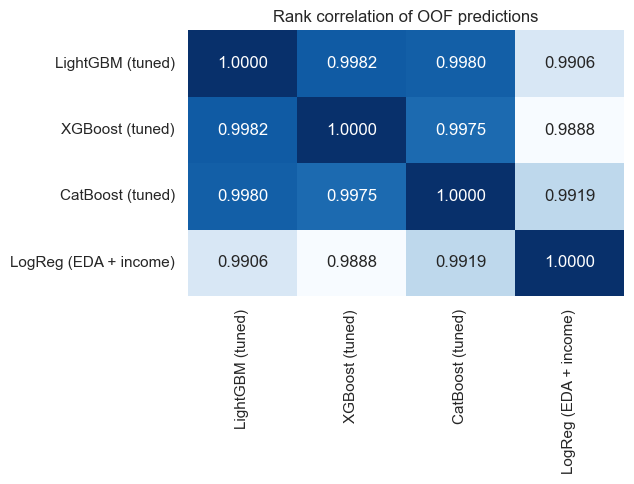

In [27]:
BOOSTERS = ["LightGBM (tuned)", "XGBoost (tuned)", "CatBoost (tuned)"]
ENSEMBLE_MEMBERS = BOOSTERS + ["LogReg (EDA + income)"]

Z_oof = pd.DataFrame({name: to_logit(results[name]["oof"]) for name in ENSEMBLE_MEMBERS})
Z_test = pd.DataFrame({name: to_logit(results[name]["test_pred"]) for name in ENSEMBLE_MEMBERS})

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(Z_oof.corr(method="spearman"), annot=True, fmt=".4f", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Rank correlation of OOF predictions")
plt.tight_layout()
plt.show()

In [28]:
class MeanLogOdds:
    """Equal-weight mean of the chosen members' log-odds; nothing is learned from the labels."""

    def __init__(self, members):
        self.members = members

    def fit(self, Z, y):
        self.weights_ = pd.Series(
            [1 / len(self.members) if col in self.members else 0.0 for col in Z.columns], index=Z.columns
        )
        return self

    def predict(self, Z):
        return expit(Z.values @ self.weights_.values)


class HillClimbing:
    """Greedy ensemble selection with replacement (Caruana et al., 2004), maximizing AUC.

    Starts from the best single member, then repeatedly adds the member whose extra copy most improves
    the blend's AUC, until the gain drops below `tol` or `max_steps` selections are made. Weights are the
    selection counts, normalized to sum to 1.
    """

    def __init__(self, max_steps=25, tol=1e-6):
        self.max_steps = max_steps
        self.tol = tol

    def fit(self, Z, y):
        values = Z.values
        counts = np.zeros(values.shape[1])
        single_aucs = [roc_auc_score(y, values[:, j]) for j in range(values.shape[1])]
        first = int(np.argmax(single_aucs))
        counts[first] = 1
        blend_sum, blend_auc = values[:, first].copy(), single_aucs[first]
        for _ in range(self.max_steps - 1):
            # a sum of log-odds ranks rows exactly like their mean, so AUC can be scored on the sum
            trial_aucs = [roc_auc_score(y, blend_sum + values[:, j]) for j in range(values.shape[1])]
            j = int(np.argmax(trial_aucs))
            if trial_aucs[j] - blend_auc < self.tol:
                break
            counts[j] += 1
            blend_sum += values[:, j]
            blend_auc = trial_aucs[j]
        self.weights_ = pd.Series(counts / counts.sum(), index=Z.columns)
        return self

    def predict(self, Z):
        return expit(Z.values @ self.weights_.values)


class LogisticStacker:
    """Logistic regression on the members' log-odds; the intercept also recalibrates the blend."""

    def fit(self, Z, y):
        self.model_ = LogisticRegression(max_iter=1000).fit(Z.values, y)
        self.weights_ = pd.Series(self.model_.coef_[0], index=Z.columns)
        return self

    def predict(self, Z):
        return self.model_.predict_proba(Z.values)[:, 1]


BLENDS = {
    "Blend: mean log-odds (boosters)": lambda: MeanLogOdds(BOOSTERS),
    "Blend: hill climbing": HillClimbing,
    "Blend: LR stacker": LogisticStacker,
}

Blend: mean log-odds (boosters)        OOF AUC = 0.94604  (fold std 0.00061)  0s


Blend: hill climbing                   OOF AUC = 0.94603  (fold std 0.00061)  8s


Blend: LR stacker                      OOF AUC = 0.94603  (fold std 0.00061)  1s

best single model: XGBoost (tuned)
Blend: mean log-odds (boosters)  vs  XGBoost (tuned): +0.00008 ± 0.00003   per fold [1.1e-04 9.0e-05 5.0e-05 8.0e-05 5.0e-05]
Blend: hill climbing  vs  XGBoost (tuned): +0.00007 ± 0.00003   per fold [1.1e-04 9.0e-05 4.0e-05 8.0e-05 3.0e-05]
Blend: LR stacker  vs  XGBoost (tuned): +0.00008 ± 0.00003   per fold [1.1e-04 9.0e-05 5.0e-05 8.0e-05 4.0e-05]


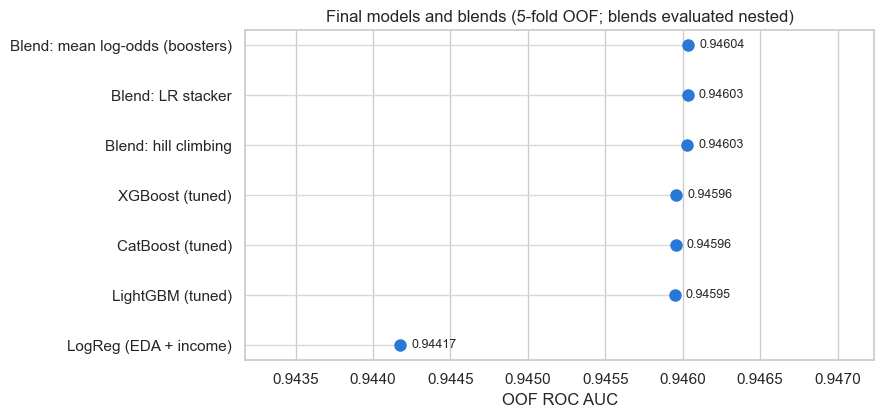

,Blend: mean log-odds (boosters),Blend: hill climbing,Blend: LR stacker
member,,,
LightGBM (tuned),0.333,0.333,0.306
XGBoost (tuned),0.333,0.333,0.337
CatBoost (tuned),0.333,0.333,0.342
LogReg (EDA + income),0.000,0.000,0.018


In [29]:
blend_weights = {}
for name, make_blend in BLENDS.items():
    start = time.time()
    oof = np.zeros(len(y))
    for trn_idx, val_idx in folds:
        # nested: the weights that score this fold were fit without it
        fold_blend = make_blend().fit(Z_oof.iloc[trn_idx], y[trn_idx])
        oof[val_idx] = fold_blend.predict(Z_oof.iloc[val_idx])
    full_blend = make_blend().fit(Z_oof, y)  # weights for the test set use all five folds
    blend_weights[name] = full_blend.weights_
    r = store_result(name, oof, full_blend.predict(Z_test), seconds=time.time() - start, save=True)
    print(f"{name:38s} OOF AUC = {r['auc']:.5f}  (fold std {np.std(r['fold_aucs']):.5f})  {r['seconds']:.0f}s")

FINAL_CANDIDATES = ENSEMBLE_MEMBERS + list(BLENDS)
best_single = max(ENSEMBLE_MEMBERS, key=lambda name: results[name]["auc"])
print(f"\nbest single model: {best_single}")
for name in BLENDS:
    compare(best_single, name)

plot_auc(FINAL_CANDIDATES, "Final models and blends (5-fold OOF; blends evaluated nested)")
pd.DataFrame(blend_weights).round(3).rename_axis("member")

**What to expect.** The members are highly correlated (see the heatmap), so blends gain little. In
development, an equal-weight blend of the three *untuned* boosters beat the best of them by only +0.00006,
and adding the linear model at equal weight made it worse (0.94556 vs 0.94567) — which is why the no-fit rule
uses the boosters only, and the fitted rules decide how much of the linear model to use. A fitted blend is
only worth submitting if it beats the best single model in the nested evaluation; §12 picks by exactly that
score. In the weights table, the stacker's coefficients are raw log-odds weights and needn't sum to 1: a sum
above 1 means it also sharpens the blend, which changes calibration but not AUC.

## 10. Interpretation — SHAP

SHAP values come from LightGBM's built-in `pred_contrib` (no extra package), for the tuned LightGBM refit
on the §7 holdout split. Each value is one feature's contribution to one prediction in log-odds, so the
plots show *how* the model uses each feature — and whether that matches the EDA.

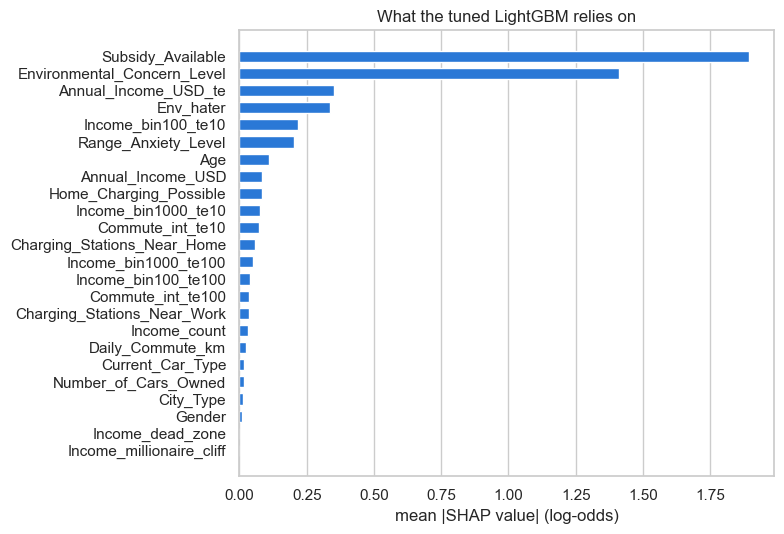

In [30]:
explain_model = lgb_fit(
    lgb.LGBMClassifier(
        **{**LGB_BASE_PARAMS, **best_params["lightgbm"], "learning_rate": FINAL_LR["lightgbm"], "n_estimators": 20000}
    ),
    H_trn, y_h_trn, H_val, y_h_val, stopping_rounds=300,
)
shap_sample = H_val.sample(20_000, random_state=SEED)
contrib = explain_model.predict(shap_sample, pred_contrib=True)  # last column is the base value
shap_values = pd.DataFrame(contrib[:, :-1], columns=shap_sample.columns, index=shap_sample.index)
mean_abs_shap = shap_values.abs().mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=COLORS[0], height=0.65)
ax.grid(axis="y", visible=False)
ax.set_xlabel("mean |SHAP value| (log-odds)")
ax.set_title("What the tuned LightGBM relies on")
plt.tight_layout()
plt.show()

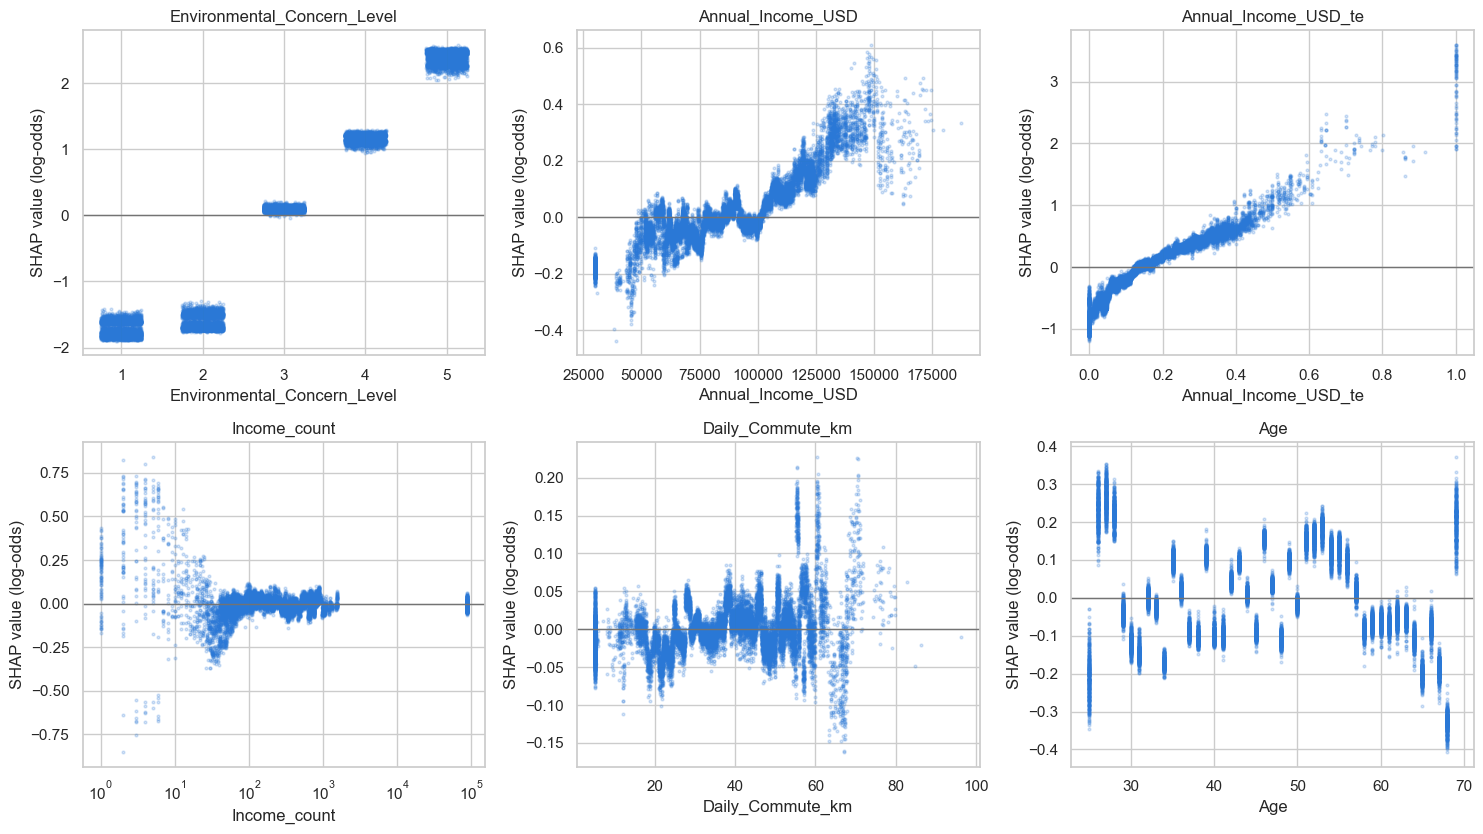

mean SHAP value (log-odds)
Subsidy_Available      No                            -2.532
                       Yes                            1.505
Range_Anxiety_Level    High                          -1.862
                       Low                            0.111
                       Medium                        -1.033
Home_Charging_Possible No                            -0.133
                       Yes                            0.060
City_Type              Rural                         -0.010
                       Suburban                      -0.014
                       Urban                          0.016

In [31]:
dependence_cols = [
    "Environmental_Concern_Level",
    "Annual_Income_USD",
    "Annual_Income_USD_te",
    "Income_count",
    "Daily_Commute_km",
    "Age",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for ax, col in zip(axes.flat, dependence_cols):
    x = shap_sample[col].astype(float).values
    if col == "Environmental_Concern_Level":
        x = x + rng.uniform(-0.25, 0.25, len(x))  # jitter the 5 levels so the points are visible
    ax.scatter(x, shap_values[col], s=4, alpha=0.2, color=COLORS[0], rasterized=True)
    ax.axhline(0, color="0.45", lw=1)
    if col == "Income_count":
        ax.set_xscale("log")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("SHAP value (log-odds)")
plt.tight_layout()
plt.show()

categorical_effects = pd.concat(
    {
        col: shap_values[col].groupby(shap_sample[col].astype(str)).mean()
        for col in ["Subsidy_Available", "Range_Anxiety_Level", "Home_Charging_Possible", "City_Type"]
    }
)
categorical_effects.rename("mean SHAP value (log-odds)").to_frame().round(3)

**What to check.** Whether the model agrees with the EDA: `Subsidy_Available` and
`Environmental_Concern_Level` should dominate, with concern level pushing predictions up step by step, and
Medium/High range anxiety should push them down. For income, look at how the three income columns share the
work: raw income should carry the smooth upward trend and the drop at the 30,000 floor, the target encoding
should add a roughly increasing effect on top, and `Income_count` should push the most repeated values down,
as §6's decile plot suggests.

## 11. Diagnostics

For the best final model or blend by OOF AUC: ROC curve and calibration, then AUC inside each EDA segment
compared with the §5 LightGBM baseline — which shows *where* the gains came from.

best model: Blend: mean log-odds (boosters)


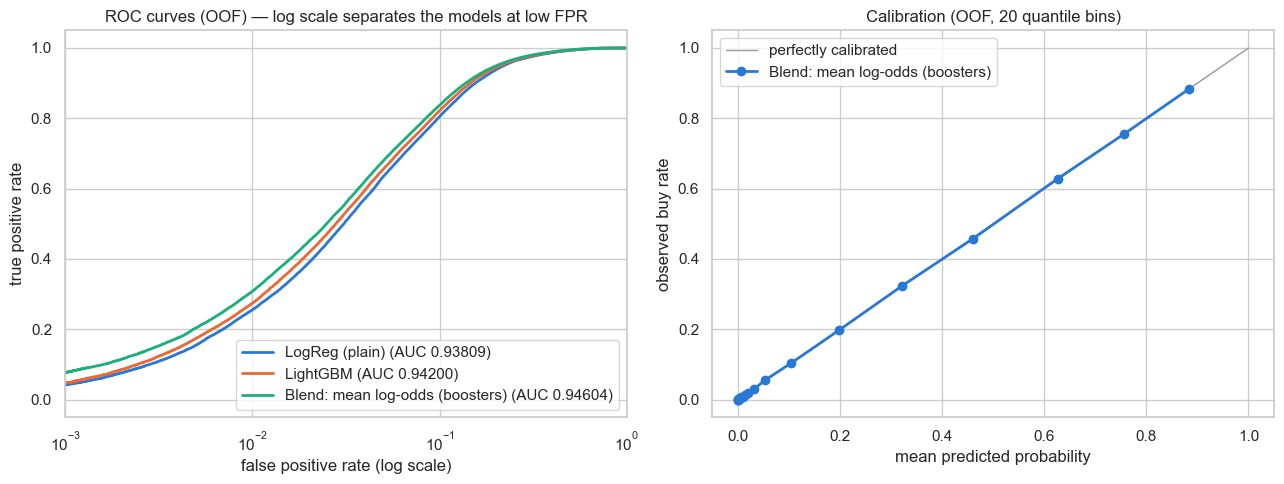

In [32]:
best_name = max(FINAL_CANDIDATES, key=lambda name: results[name]["auc"])
print("best model:", best_name)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for color, name in zip(COLORS, ["LogReg (plain)", "LightGBM", best_name]):
    fpr, tpr, _ = roc_curve(y, results[name]["oof"])
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC {results[name]['auc']:.5f})")
axes[0].set_xscale("log")
axes[0].set_xlim(1e-3, 1)
axes[0].set_xlabel("false positive rate (log scale)")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curves (OOF) — log scale separates the models at low FPR")
axes[0].legend(loc="lower right")

prob_true, prob_pred = calibration_curve(y, results[best_name]["oof"], n_bins=20, strategy="quantile")
axes[1].plot([0, 1], [0, 1], color="0.6", lw=1, label="perfectly calibrated")
axes[1].plot(prob_pred, prob_true, "o-", color=COLORS[0], lw=2, markersize=6, label=best_name)
axes[1].set_xlabel("mean predicted probability")
axes[1].set_ylabel("observed buy rate")
axes[1].set_title("Calibration (OOF, 20 quantile bins)")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

In [33]:
segment_frame = train[FEATURES].assign(
    Income_at_floor=np.where(train["Annual_Income_USD"] <= INCOME_FLOOR, "yes", "no")
)
rows = []
for col in [
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Environmental_Concern_Level",
    "Home_Charging_Possible",
    "City_Type",
    "Income_at_floor",
]:
    for level, idx in segment_frame.groupby(col).indices.items():
        if y[idx].min() == y[idx].max():
            continue  # AUC is undefined when a segment has only one class
        rows.append(
            {
                "segment": f"{col} = {level}",
                "rows": len(idx),
                "positives": int(y[idx].sum()),
                "AUC baseline": roc_auc_score(y[idx], results["LightGBM"]["oof"][idx]),
                "AUC best": roc_auc_score(y[idx], results[best_name]["oof"][idx]),
            }
        )
segment_auc = pd.DataFrame(rows).set_index("segment")
segment_auc["gain"] = segment_auc["AUC best"] - segment_auc["AUC baseline"]
segment_auc.round(4)

,rows,positives,AUC baseline,AUC best,gain
segment,,,,,
Subsidy_Available = No,248756,1432,0.8763,0.8861,0.0098
Subsidy_Available = Yes,419909,115347,0.9043,0.9111,0.0068
Range_Anxiety_Level = High,2194,3,0.9833,0.9834,0.0002
Range_Anxiety_Level = Low,603972,114167,0.9393,0.9435,0.0043
Range_Anxiety_Level = Medium,62499,2609,0.9333,0.9376,0.0044
Environmental_Concern_Level = 1.0,147476,834,0.8259,0.8374,0.0115
Environmental_Concern_Level = 2.0,135133,2889,0.8385,0.8497,0.0113
Environmental_Concern_Level = 3.0,127351,14126,0.8507,0.8645,0.0137
Environmental_Concern_Level = 4.0,130469,32467,0.8658,0.8770,0.0113


**How to read it.** Calibration checks that predicted probabilities match observed buy rates — AUC doesn't
need it, but it matters if the probabilities are ever used directly. In the segment table, AUC *within* a
segment measures ranking among similar people, so most segment AUCs sit below the overall AUC: telling
subsidy from no-subsidy people apart is the easy part. The `gain` column shows where the income features,
tuning and blending helped most. Segments with few buyers (e.g. `Range_Anxiety_Level = High`) have noisy AUCs.

## 12. Submission

The submission uses whichever final model or blend has the best **OOF** AUC. The blends' scores are nested,
so they compete fairly with the single models. Test predictions are already averaged over the 5 fold models.

In [34]:
final_table = pd.Series({name: results[name]["auc"] for name in FINAL_CANDIDATES}).sort_values(ascending=False)
best_name = final_table.index[0]
print(final_table.round(5).to_string())
print(f"\nselected: {best_name}  (OOF AUC {final_table.iloc[0]:.5f})")

submission = pd.DataFrame({"id": test["id"], TARGET: results[best_name]["test_pred"]})
submission.to_csv("submission.csv", index=False)

sample = pd.read_csv(DATA_DIR / "sample_submission.csv")
probs = submission[TARGET]

print()
print("shape matches sample :", submission.shape == sample.shape)
print("ids match sample     :", submission["id"].equals(sample["id"]))
print("columns              :", list(submission.columns))
print(f"prob range           : {probs.min():.5f} - {probs.max():.5f}")
print(f"mean predicted prob  : {probs.mean():.5f} | train positive rate: {y.mean():.5f}")
print("nulls                :", int(probs.isnull().sum()))
submission.head()

Blend: mean log-odds (boosters)    0.94604
Blend: LR stacker                  0.94603
Blend: hill climbing               0.94603
XGBoost (tuned)                    0.94596
CatBoost (tuned)                   0.94596
LightGBM (tuned)                   0.94595
LogReg (EDA + income)              0.94417

selected: Blend: mean log-odds (boosters)  (OOF AUC 0.94604)



shape matches sample : True
ids match sample     : True
columns              : ['id', 'Will_Buy_EV']
prob range           : 0.00000 - 0.99965
mean predicted prob  : 0.17482 | train positive rate: 0.17465
nulls                : 0


,id,Will_Buy_EV
0,668665,0.033612
1,668666,0.017211
2,668667,0.003408
3,668668,0.002299
4,668669,0.025518


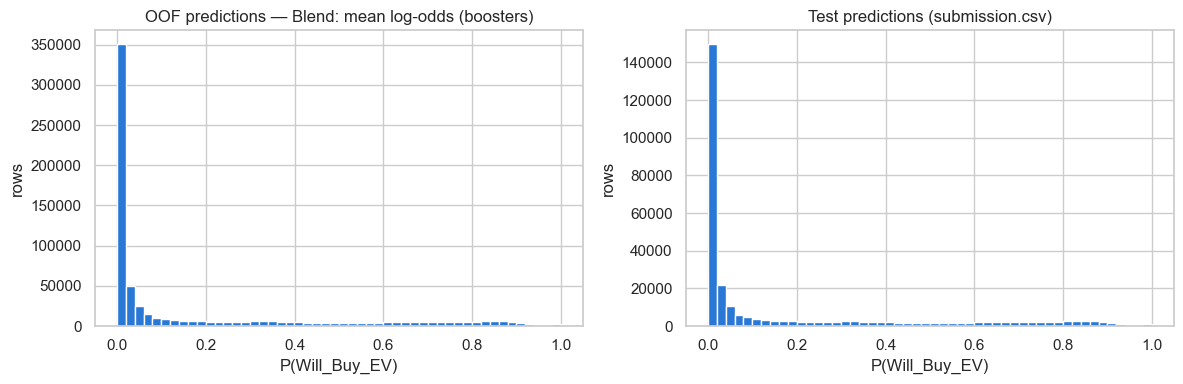

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(results[best_name]["oof"], bins=50, color=COLORS[0])
axes[0].set_title(f"OOF predictions — {best_name}")
axes[1].hist(submission[TARGET], bins=50, color=COLORS[0])
axes[1].set_title("Test predictions (submission.csv)")
for ax in axes:
    ax.set_xlabel("P(Will_Buy_EV)")
    ax.set_ylabel("rows")
plt.tight_layout()
plt.show()

## 13. Summary

In [36]:
summary = (
    pd.DataFrame(
        {
            name: {
                "OOF AUC": r["auc"],
                "fold std": np.std(r["fold_aucs"]),
                "gain vs LogReg (plain)": r["auc"] - results["LogReg (plain)"]["auc"],
                "seconds": r["seconds"],
            }
            for name, r in results.items()
        }
    )
    .T.sort_values("OOF AUC", ascending=False)
    .round({"OOF AUC": 5, "fold std": 5, "gain vs LogReg (plain)": 5, "seconds": 0})
)
print(f"notebook runtime: {(time.time() - NOTEBOOK_START) / 60:.0f} min")
summary

notebook runtime: 63 min


,OOF AUC,fold std,gain vs LogReg (plain),seconds
Blend: mean log-odds (boosters),0.94604,0.00061,0.00794,0.0
Blend: LR stacker,0.94603,0.00061,0.00794,1.0
Blend: hill climbing,0.94603,0.00061,0.00793,8.0
XGBoost (tuned),0.94596,0.00063,0.00786,418.0
CatBoost (tuned),0.94596,0.00057,0.00786,206.0
LightGBM (tuned),0.94595,0.00063,0.00785,1185.0
LightGBM + income count + TE + multi-scale bins,0.94581,0.00062,0.00771,58.0
LightGBM + income count + TE,0.94555,0.00065,0.00745,53.0
LightGBM + income count + TE (+ categoricals),0.94552,0.00064,0.00742,58.0
LogReg (EDA + income),0.94417,0.00062,0.00608,21.0


**The path so far** — numbers from development runs on the same folds and seed; the table above holds this
run's numbers, including the tuned models and blends:

| Step | OOF AUC | What it showed |
|---|---|---|
| Plain logistic regression | 0.93809 | baseline |
| + EDA splines, one-hot, floor flags | 0.93929 | the EDA's non-linear shapes are real (+0.0012) |
| LightGBM, raw features | 0.94200 | trees add +0.0027; XGBoost and CatBoost within 0.0005 |
| LightGBM, depth-1 trees only | 0.94183 | interactions are worth only ~0.0002 |
| + income count | 0.94310 | the generator reuses income values (+0.0011) |
| + income target encoding | 0.94555 | which label goes with a value carries over (+0.0024) |
| XGBoost / CatBoost with the same features, untuned | 0.94561 / 0.94549 | the gain carries over to other libraries |

**Conclusions**
- The EDA picked the right features — subsidy, environmental concern, income, range anxiety — but its
  gate-like subsidy pattern turned out additive on the log-odds scale, so per-segment models and feature
  crosses didn't help.
- The largest gain came from treating income as an *identity*, not only a quantity. That's an artifact of the
  synthetic generator, so don't expect it to transfer to real-world data; within this competition it's
  legitimate, since neither income feature sees validation labels.
- Ideas that sounded promising but didn't help: floor flags, discrete numerics as categories, appending the
  original survey, and target-encoded feature pairs.
- The members are highly correlated, so blending is a final polish rather than a step change.

**Next ideas:** more Optuna trials for the strongest booster, extra seeds in `FINAL_SEEDS`, and a more
different ensemble member — for example a neural network on the same features.